In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

import sys
sys.path.insert(0, "../..")
from pipeline import preprocess as canonical_preprocess  # median imputation + MinMaxScaler, split-first


In [2]:
df = pd.read_csv("../../data/raw/diabetes.csv")

X_train, X_test, y_train, y_test = canonical_preprocess(
    "../../data/raw/diabetes.csv"
)


In [3]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

In [4]:
X_train, X_test, y_train, y_test = canonical_preprocess(
    "../../data/raw/diabetes.csv"
)


In [5]:
dt = DecisionTreeClassifier(
    random_state=42
)

In [6]:
param_grid = {
    "max_depth": list(range(3, 11))
}

In [7]:
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="f1"
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with hig

In [8]:
print("Best Parameters:")

print(grid_search.best_params_)

Best Parameters:
{'max_depth': 4}


In [9]:
best_dt = grid_search.best_estimator_

In [10]:
y_pred = best_dt.predict(X_test)

y_prob = best_dt.predict_proba(X_test)[:,1]

In [11]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

auc = roc_auc_score(
    y_test,
    y_prob
)

ROC data saved successfully.


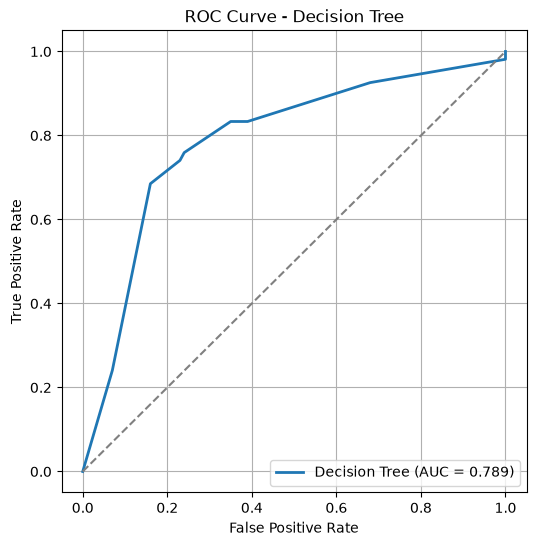

In [12]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import os

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

os.makedirs("../../results/roc", exist_ok=True)

roc_df = pd.DataFrame({
    "FPR": fpr,
    "TPR": tpr
})

roc_df.to_csv(
    "../../results/roc/roc_decision_tree.csv",
    index=False
)

print("ROC data saved successfully.")


os.makedirs("../../results/roc", exist_ok=True)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Decision Tree (AUC = {auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")

plt.legend(loc="lower right")
plt.grid(True)

plt.savefig(
    "../../results/roc/roc_decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1 Score :", f1)

print("AUC ROC  :", auc)

Accuracy : 0.7857142857142857
Precision: 0.6981132075471698
Recall   : 0.6851851851851852
F1 Score : 0.6915887850467289
AUC ROC  : 0.7887037037037039


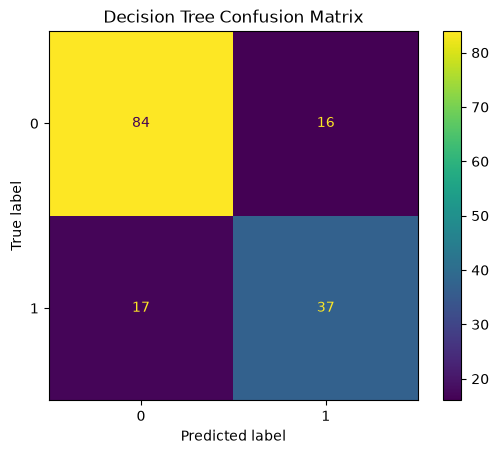

In [14]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Decision Tree Confusion Matrix")
import os

os.makedirs("../../results/matrix", exist_ok=True)
plt.savefig(
    "../../results/matrix/decision_tree_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
results = pd.read_csv(
    "../../results/results_log.csv"
)

In [16]:
new_row = pd.DataFrame({
    "model": ["DT"],
    "accuracy": [accuracy],
    "precision": [precision],
    "recall": [recall],
    "f1": [f1],
    "auc_roc": [auc]
})

In [17]:
log_path = "../../results/results_log.csv"

try:
    results = pd.read_csv(log_path)
except FileNotFoundError:
    results = pd.DataFrame(
        columns=["model", "accuracy", "precision", "recall", "f1", "auc_roc"]
    )

new_row = pd.DataFrame({
    "model": ["DT"],
    "accuracy": [round(accuracy, 4)],
    "precision": [round(precision, 4)],
    "recall": [round(recall, 4)],
    "f1": [round(f1, 4)],
    "auc_roc": [round(auc, 4)]
})

if "DT" in results["model"].values:
    results.loc[
        results["model"] == "DT",
        ["accuracy", "precision", "recall", "f1", "auc_roc"]
    ] = [
        round(accuracy, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4),
        round(auc, 4)
    ]
else:
    results = pd.concat([results, new_row], ignore_index=True)

results.to_csv(log_path, index=False)

print("Decision Tree results saved successfully!")

results

Decision Tree results saved successfully!


,model,accuracy,precision,recall,f1,auc_roc
0,Logistic Regression,0.707792,0.604651,0.481481,0.536082,0.807037
1,RF,0.766234,0.695652,0.592593,0.640000,0.817870
2,DT,0.785700,0.698100,0.685200,0.691600,0.788700
3,SVM,0.707792,0.604651,0.481481,0.536082,0.816852
4,Static MLP,0.727273,0.630435,0.537037,0.580000,0.840000
